Using the Mauna Lua CO2 dataset (monthly) perform forecasting using an MLP and compare the results with that of MA (Moving Average) and ARMA (Auto Regressive Moving Average)  models. 
Main setting: use previous “K” readings to predict next “T” reading. Example, if “K=3” and “T=1” then we use data from Jan, Feb, March and then predict the reading for April.
Comment on why you observe such results. 
For MA or ARMA you can use any library or implement it from scratch. The choice of MLP is up to you.

In [2]:
# Code for forecasting CO2 levels using MLP, MA, and ARMA models
# Import necessary libraries
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.ar_model import AutoReg
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error


In [3]:
# Load the Mauna Lua CO2 dataset
data = pd.read_csv('co2_mm_mlo.csv')

In [4]:

# Define parameters
K = 3  # Number of previous readings to consider
T = 1  # Number of future readings to predict


In [5]:

# Prepare the data for modeling
X, y = [], []
for i in range(len(data)-K-T+1):
    X.append(data['decimal date'][i:i+K])
    y.append(data['average'][i+K:i+K+T])


In [6]:

# Split the data into training and testing sets
split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = np.array(X[:split]), np.array(X[split:]), np.array(y[:split]), np.array(y[split:])


In [7]:

# Implement Moving Average (MA) model
ma_model = np.mean(X_train, axis=1)
ma_mse = mean_squared_error(y_train, ma_model)


In [8]:
# # Implement AutoRegressive Moving Average (ARMA) model
# arma_model = ARIMA(X_train).fit()
# arma_forecast = arma_model.forecast(steps=len(X_test))[0]
# arma_mse = mean_squared_error(y_test, arma_forecast)


In [9]:

# Implement Multi-Layer Perceptron (MLP) model
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000).fit(X_train, y_train)
mlp_forecast = mlp_model.predict(X_test)
mlp_mse = mean_squared_error(y_test, mlp_forecast)


c:\Users\jaide\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1623: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [10]:

# Compare the Mean Squared Error (MSE) of the models
print(f'MA Model MSE: {ma_mse}')
print(f'MLP Model MSE: {mlp_mse}')
# print(f'ARMA Model MSE: {arma_mse}')


MA Model MSE: 2681305.2586193723
MLP Model MSE: 2677.2350377181215


ARIMA

In [11]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

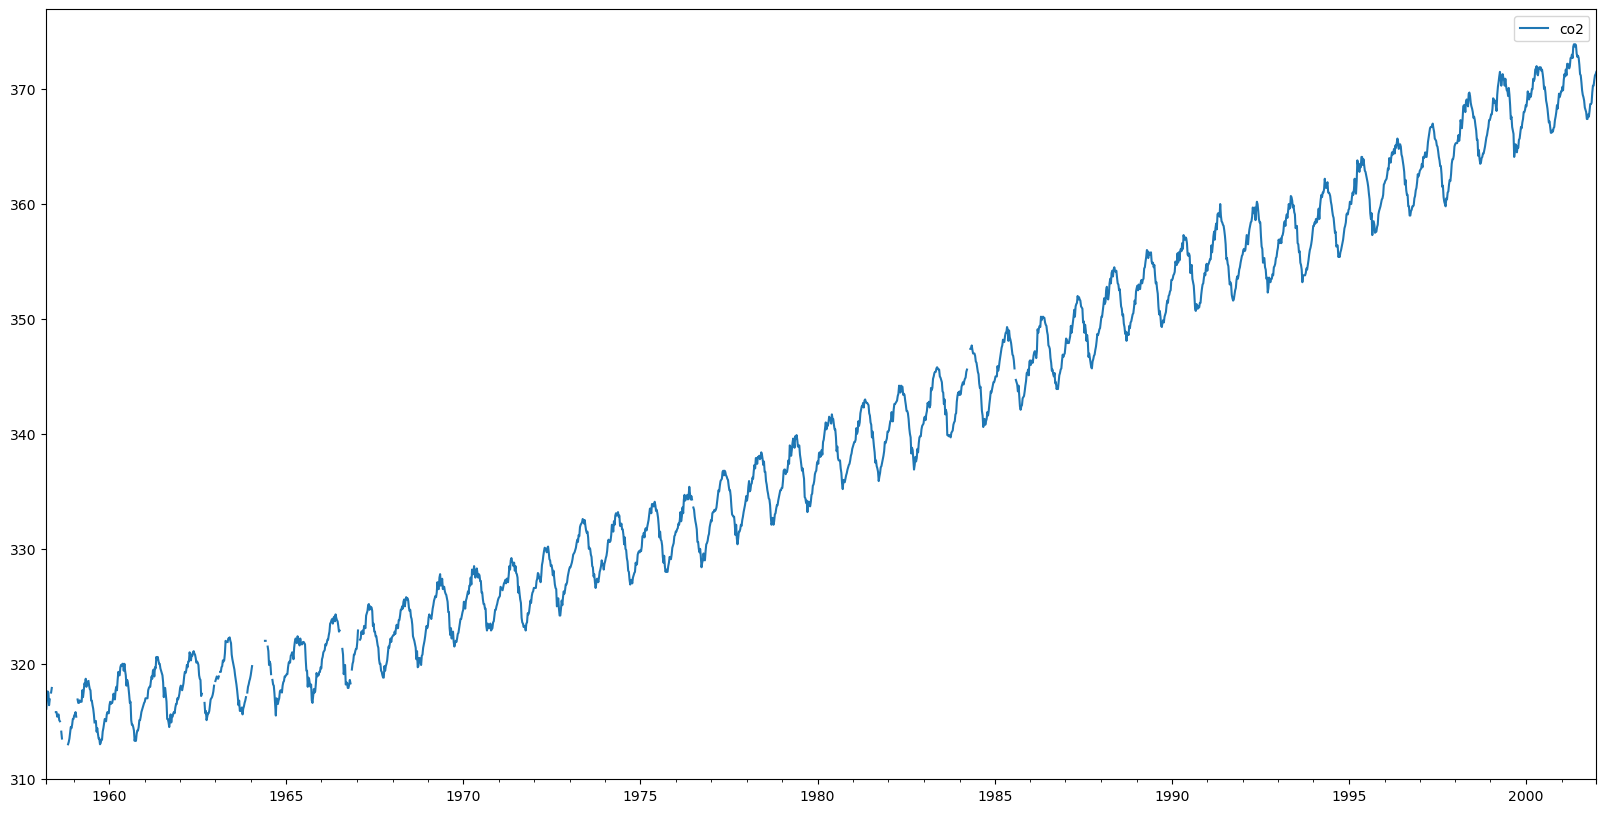

In [12]:
df = sm.datasets.co2.load_pandas().data
df.plot(figsize = (20,10))
plt.show()

In [13]:
train, test = train_test_split(df, test_size = 0.2,random_state = 13, shuffle = False)
p, d, q = 1,1,1
fcst = []
for step in range(test.shape[0]):
    print("The step is: ", step, "out of: ", test.shape[0])
    try:
        arima = ARIMA(train, order = (K,1,1))
        arima_final = arima.fit()
        prediction = arima_final.forecast(steps = T)
        fcst.append(prediction[0])
        train = train.append(pd.Series(test.iloc[step]))
    except:
        error = -99999
        print("error")
        fcst.append(error)
        tmp = test.iloc[step]
        tmp[0] = error
        train = train.append(pd.Series(tmp))

The step is:  0 out of:  457
The step is:  1 out of:  457
The step is:  2 out of:  457
The step is:  3 out of:  457
The step is:  4 out of:  457
The step is:  5 out of:  457
The step is:  6 out of:  457
The step is:  7 out of:  457
The step is:  8 out of:  457
The step is:  9 out of:  457
The step is:  10 out of:  457
The step is:  11 out of:  457
The step is:  12 out of:  457
The step is:  13 out of:  457
The step is:  14 out of:  457
The step is:  15 out of:  457
The step is:  16 out of:  457
The step is:  17 out of:  457
The step is:  18 out of:  457
The step is:  19 out of:  457
The step is:  20 out of:  457
The step is:  21 out of:  457
The step is:  22 out of:  457
The step is:  23 out of:  457
The step is:  24 out of:  457
The step is:  25 out of:  457
The step is:  26 out of:  457
The step is:  27 out of:  457
The step is:  28 out of:  457
The step is:  29 out of:  457
The step is:  30 out of:  457
The step is:  31 out of:  457
The step is:  32 out of:  457
The step is:  33 out

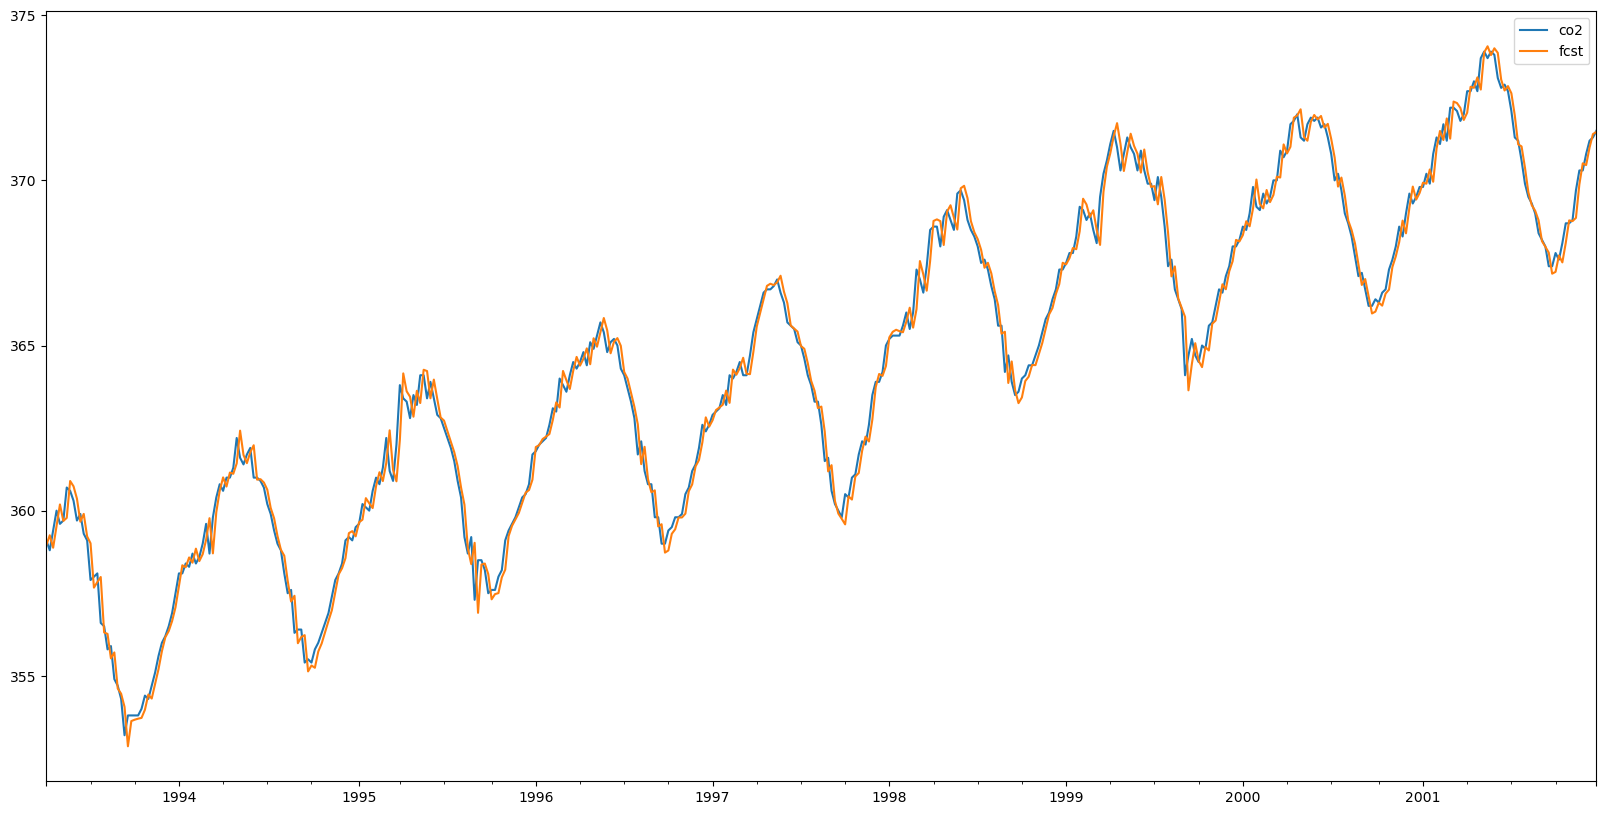

In [14]:
test["fcst"] = fcst
test.plot(figsize = (20,10))
plt.show()

In [15]:
mean_squared_error(test.co2, test.fcst)


0.2368231137632519